# H&M Future Repurchase Propensity — Nonlinear Challenger Model

This analysis tests whether nonlinear relationships and interactions improve the prediction of future 120-day repurchase among Recent Occasional customers.

The nonlinear model uses the same customer features and the same training, validation, and untouched-test partitions as the selected Logistic Regression model.

Validation performance is examined before the nonlinear model is refitted on the combined training and validation data and evaluated once on the shared untouched test set.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("/Volumes/USB/H&M Data/recent_occasional_logistic_regression_input.csv")

In [3]:
df.shape

Out[1]: (328787, 12)


## Model Specification

The nonlinear challenger uses the same eight predictors as the selected **Expanded + Channel Preference** Logistic Regression model.

In [4]:
model_features = ["recency","log_frequency","log_monetary","regular_fashion_news","club_member_active","product_group_entropy","both_channels","channel_2_item_share"]

In [5]:
X = df[model_features].copy()
X["recency"] = X["recency"].astype(float)
y = df["repurchase"]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_development, X_test, y_development, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

X_train, X_validation, y_train, y_validation = train_test_split(X_development,y_development,test_size=0.25,random_state=42,stratify=y_development)

In [8]:
print(X_train.shape)
print(X_validation.shape)
print(X_test.shape)

(197271, 8)
(65758, 8)
(65758, 8)


In [9]:
print(y_train.mean())
print(y_validation.mean())
print(y_test.mean())

0.3791079276730994
0.3791021624745278
0.3791021624745278


## Histogram-Based Gradient Boosting

Histogram-Based Gradient Boosting can capture nonlinear relationships, thresholds, and interactions among customer behaviours.

Unlike logistic regression, the model does not require continuous variables to be standardized because it learns decision thresholds rather than distance-based relationships.

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [11]:
nonlinear_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=15,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42
)

In [12]:
nonlinear_model.fit(X_train, y_train)

Out[1]: 
HistGradientBoostingClassifier(l2_regularization=1.0, learning_rate=0.05,
                               max_iter=200, max_leaf_nodes=15,
                               min_samples_leaf=50, random_state=42)


  File "/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/context.py", line 249, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_darwin()
  File "/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/context.py", line 318, in _count_physical_cores_darwin
    return int(cpu_info)


In [13]:
nonlinear_validation_probability = nonlinear_model.predict_proba(X_validation)[:, 1]

In [14]:
print(nonlinear_validation_probability.min(),nonlinear_validation_probability.max())

0.0927299255154808 0.8247051115147416


## Nonlinear Model Performance

The nonlinear specification is first evaluated on the validation set using ROC AUC, PR AUC, and Brier score.

After this validation check, it is refitted on the combined training and validation data and evaluated on the same untouched test customers used by the final Logistic Regression model.

In [15]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import brier_score_loss

In [16]:
nonlinear_validation_roc_auc = roc_auc_score(y_validation,nonlinear_validation_probability)

In [17]:
nonlinear_validation_pr_auc = average_precision_score(y_validation,nonlinear_validation_probability)

In [18]:
nonlinear_validation_brier = brier_score_loss(y_validation,nonlinear_validation_probability)

In [19]:
validation_metrics = pd.DataFrame({
    "Model": ["Nonlinear Challenger"],
    "ROC AUC": [nonlinear_validation_roc_auc],
    "PR AUC": [nonlinear_validation_pr_auc],
    "Brier Score": [nonlinear_validation_brier]
})

In [20]:
display(validation_metrics.round(4))

,Model,ROC AUC,PR AUC,Brier Score
0,Nonlinear Challenger,0.694,0.5683,0.21


### Validation Performance Result

On the validation set, the nonlinear challenger achieved a ROC AUC of **0.6940**, PR AUC of **0.5683**, and Brier score of **0.2100**.

The selected Logistic Regression specification achieved a validation ROC AUC of **0.6895** and PR AUC of **0.5631**.

The nonlinear challenger therefore shows a small validation-stage improvement in ranking performance. It is next refitted on the full development sample and evaluated on the shared untouched test set.

## Final Model Refit and Untouched-Test Evaluation

The nonlinear model is now refitted on the combined training and validation data using the same predefined model settings.

Its final performance is evaluated on exactly the same untouched test customers used by the final Logistic Regression model.

In [21]:
final_nonlinear_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=15,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42
)

In [22]:
final_nonlinear_model.fit(X_development,y_development)

Out[1]: 
HistGradientBoostingClassifier(l2_regularization=1.0, learning_rate=0.05,
                               max_iter=200, max_leaf_nodes=15,
                               min_samples_leaf=50, random_state=42)


In [23]:
nonlinear_probability = final_nonlinear_model.predict_proba(X_test)[:,1]

In [24]:
nonlinear_roc_auc = roc_auc_score(y_test,nonlinear_probability)

In [25]:
nonlinear_pr_auc = average_precision_score(y_test,nonlinear_probability)

In [26]:
nonlinear_brier = brier_score_loss(y_test,nonlinear_probability)

In [27]:
final_test_metrics = pd.DataFrame({
    "Model": ["Nonlinear Challenger"],
    "ROC AUC": [nonlinear_roc_auc],
    "PR AUC": [nonlinear_pr_auc],
    "Brier Score": [nonlinear_brier]
})

In [28]:
display(final_test_metrics.round(4))

,Model,ROC AUC,PR AUC,Brier Score
0,Nonlinear Challenger,0.6887,0.5608,0.2113


### Final Test Performance Result

On the shared untouched test set, the nonlinear challenger achieved a ROC AUC of **0.6887**, PR AUC of **0.5608**, and Brier score of **0.2113**.

The final Logistic Regression model achieved a ROC AUC of **0.6851**, PR AUC of **0.5559**, and Brier score of **0.2122** on the same test customers.

The nonlinear model therefore provides a small improvement in ranking performance and probability accuracy. Decile lift is examined next to determine whether this improvement creates materially stronger CRM segmentation.

## Decile Lift Analysis

Customers are ranked by nonlinear predicted repurchase probability and divided into ten equally sized groups. Decile 1 contains the highest-propensity customers, while Decile 10 contains the lowest-propensity customers.

In [29]:
overall_repurchase_rate = y_test.mean()

In [30]:
nonlinear_lift = pd.DataFrame({"actual": y_test.to_numpy(),"probability": nonlinear_probability})

In [31]:
nonlinear_rank = nonlinear_lift["probability"].rank(method="first",ascending=False)

In [32]:
nonlinear_lift["decile"] = pd.qcut(nonlinear_rank,10,labels=range(1, 11))

In [33]:
nonlinear_deciles = nonlinear_lift.groupby("decile",observed=True).agg(
    customers=("actual", "size"),
    repurchase_rate=("actual", "mean"),
    average_probability=("probability", "mean")
).reset_index()

In [34]:
nonlinear_deciles["lift"] = (nonlinear_deciles["repurchase_rate"] / overall_repurchase_rate)

In [35]:
display(nonlinear_deciles.round(3))

,decile,customers,repurchase_rate,average_probability,lift
0,1,6576,0.654,0.661,1.724
1,2,6576,0.568,0.563,1.497
2,3,6576,0.499,0.500,1.315
3,4,6575,0.455,0.444,1.201
4,5,6576,0.387,0.389,1.020
5,6,6576,0.326,0.336,0.861
6,7,6575,0.287,0.290,0.757
7,8,6576,0.245,0.250,0.645
8,9,6576,0.210,0.213,0.555
9,10,6576,0.161,0.156,0.424


### Lift Result

On the shared untouched test set, the nonlinear model identified a top decile with a **65.4% repurchase rate** and **1.724× lift** over the customer average.

Its bottom decile had a **16.1% repurchase rate**, producing a **49.3-percentage-point separation** between the highest- and lowest-propensity groups.

The final Logistic Regression model produced a **48.9-percentage-point separation** on the same test customers. The nonlinear model therefore improves ROC AUC and PR AUC slightly, but it does not create a materially stronger top-to-bottom CRM segmentation.

## Permutation Feature Importance

Permutation importance measures how much the model’s ROC AUC decreases when one feature is randomly shuffled. A larger decrease indicates that the model depends more heavily on that feature.

In [36]:
importance_sample = X_test.sample(n=30000,random_state=42)

In [37]:
importance_target = y_test.loc[importance_sample.index]

In [38]:
from sklearn.inspection import permutation_importance

In [39]:
permutation_result = permutation_importance(
    final_nonlinear_model,
    importance_sample,
    importance_target,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [40]:
importance_table = pd.DataFrame({
    "feature": model_features,
    "importance": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
})

In [41]:
importance_table = importance_table.sort_values("importance",ascending=False)

In [42]:
display(importance_table.round(4))

,feature,importance,importance_std
1,log_frequency,0.0814,0.0026
0,recency,0.0232,0.0011
7,channel_2_item_share,0.0176,0.0009
4,club_member_active,0.0088,0.0004
3,regular_fashion_news,0.0081,0.0007
5,product_group_entropy,0.0066,0.0004
2,log_monetary,0.0013,0.0001
6,both_channels,0.0000,0.0001


### Feature-Importance Result

Historical shopping frequency was the dominant predictor in the final nonlinear model, followed by recency and Channel 2 item share.

The remaining predictive signals included active club membership, Fashion News engagement, and product-group diversity.

Historical monetary value contributed little incremental predictive information, while the standalone `both_channels` indicator added almost no additional value after Channel 2 item share and the other behavioural variables were considered.

This result suggests that the intensity of customers’ channel preference contains more useful nonlinear information than a simple binary indicator of whether they used both channels.

## Partial-Dependence Analysis

Partial-dependence plots show how the nonlinear model’s predicted repurchase probability changes across the values of important continuous variables, averaged across the test sample.

In [43]:
import matplotlib.pyplot as plt

In [44]:
from sklearn.inspection import PartialDependenceDisplay

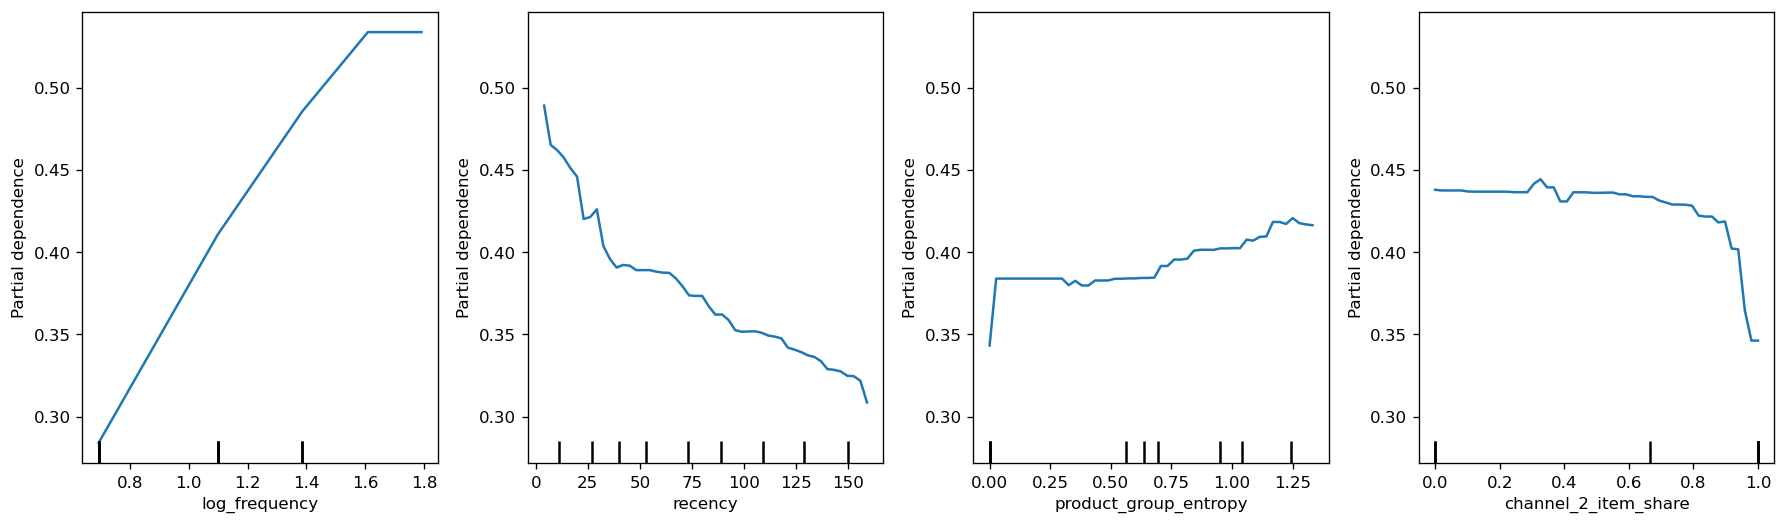

In [45]:
fig, axes = plt.subplots(1,4,figsize=(15, 4.5))

PartialDependenceDisplay.from_estimator(
    final_nonlinear_model,
    importance_sample,
    features=["log_frequency","recency","product_group_entropy","channel_2_item_share"],
    response_method="predict_proba",
    method="brute",
    grid_resolution=50,
    ax=axes)

plt.tight_layout()
plt.show()

In [46]:
channel_behaviour = np.select(
    [df["channel_2_item_share"] == 1,df["channel_2_item_share"] == 0],
    ["Channel 2 only","Channel 1 only"],
    default="Both channels")

In [47]:
channel_profile = df.assign(channel_behaviour=channel_behaviour)

In [48]:
channel_profile = channel_profile.groupby("channel_behaviour").agg(customers=("customer_id","size"),repurchase_rate=("repurchase","mean")).reset_index()

In [49]:
channel_profile["customer_share"] = (channel_profile["customers"] / len(df))

In [50]:
display(channel_profile[["channel_behaviour","customers","customer_share","repurchase_rate"]].round(3))

,channel_behaviour,customers,customer_share,repurchase_rate
0,Both channels,48127,0.146,0.573
1,Channel 1 only,66006,0.201,0.444
2,Channel 2 only,214654,0.653,0.316


### Partial-Dependence Result

1. **Historical shopping frequency** shows the strongest relationship with future repurchase propensity. Predicted probability increases substantially as customers move from one to approximately four historical shopping days.

   The incremental gain begins to plateau around four shopping days. However, customers exceeding four shopping days are rare in the Recent Occasional segment, so this represents a high-frequency signal within this cohort rather than a universal threshold.

2. **Recency** shows its sharpest deterioration during approximately the first 30–40 days following the latest purchase. Beyond this range, repurchase propensity remains lower and declines more gradually.

3. **Product-group diversity** has a positive but smaller relationship with future repurchase propensity.

4. **Channel 2 item share** remains relatively stable across most mixed-channel values but falls sharply as the share approaches 1. The descriptive channel comparison shows that this pattern is primarily driven by customers who purchased exclusively through Channel 2.

   Channel 2-only customers had a future repurchase rate of approximately **31.6%**, compared with **44.4%** for Channel 1-only customers and **57.3%** for customers who used both channels.

Together, these findings identify three useful CRM signals:

- Increasing historical shopping frequency indicates progression toward repeat purchasing.
- The 30–40-day recency range provides a potential early-intervention window.
- Channel 2 exclusivity identifies a customer group with materially lower future repurchase propensity.

## Nonlinear-Model Conclusion

On the shared untouched test set, the nonlinear challenger slightly outperformed the selected Logistic Regression model in ROC AUC, PR AUC, and Brier score. However, both models produced almost identical decile lift and top-to-bottom customer separation.

The Logistic Regression model therefore remains the preferred operational scoring model because it is easier to explain, audit, and deploy. The nonlinear model provides additional diagnostic value by revealing behavioural thresholds and patterns that the linear specification cannot show clearly.

The nonlinear analysis identifies three important CRM insights:

- Repurchase propensity increases strongly up to approximately four historical shopping days within the Recent Occasional cohort.
- Repurchase propensity deteriorates most rapidly during approximately the first 30–40 days after the latest purchase.
- Customers who purchased exclusively through Channel 2 show a sharp decline in predicted and observed future repurchase behaviour.

These findings can support differentiated CRM treatment. Channel 2-exclusive customers can be flagged as a higher-risk group, while recency and historical shopping frequency can help determine the timing and intensity of intervention.

Therefore:

- **Expanded + Channel Preference Logistic Regression:** primary interpretable scoring model
- **Histogram-Based Gradient Boosting:** nonlinear validation, threshold discovery, and CRM signal diagnosis